# Step 3 — Train NER Model
This notebook trains a spaCy Named Entity Recognition (NER) model on our resume dataset.

**What we extract from resumes:**
- Name, Email, Phone
- College, Degree, Graduation Year
- Company, Designation
- Skills, Certifications

**Pipeline:**
1. Load JSON training data
2. Convert to spaCy DocBin format
3. Train NER model
4. Evaluate on test set
5. Save model


## 1. Imports and Setup

In [1]:
import json
import random
import os
import sys
from pathlib import Path

import spacy
from spacy.tokens import DocBin
from spacy.training import Example

# Add project root to path
sys.path.append(os.path.dirname(os.getcwd()))
from config import NER_DATA_PATH, NER_MODEL_PATH, DATA_DIR, MODELS_DIR

os.makedirs(MODELS_DIR, exist_ok=True)

print("spaCy version :", spacy.__version__)
print("NER data path :", NER_DATA_PATH)
print("Model save path:", NER_MODEL_PATH)


spaCy version : 3.8.14
NER data path : c:\Users\GARG\RESUMES PBL\data\ner_training_data.json
Model save path: c:\Users\GARG\RESUMES PBL\models\ner_model


## 2. Load Training Data

In [2]:
with open(NER_DATA_PATH, encoding="utf-8") as f:
    dataset = json.load(f)

print(f"Total samples loaded: {len(dataset)}")

# Show one sample
sample = dataset[0]
print("\nSample text (first 200 chars):")
print(sample["text"][:200])
print("\nEntities:")
for ent in sample["entities"][:6]:
    start, end, label = ent
    print(f"  [{label:20s}] {sample['text'][start:end]!r}")


Total samples loaded: 1200

Sample text (first 200 chars):
Aarav Chauhan
aaravc@yahoo.com | 7654321098 | Chandigarh

EDUCATION
B.Sc in Computer Science — IIT Delhi
Graduation Year: 2023

EXPERIENCE
Data Scientist — Wipro
1 years of experience in software deve

Entities:
  [Name                ] 'Aarav Chauhan'
  [Email               ] 'aaravc@yahoo.com'
  [Phone               ] '7654321098'
  [Degree              ] 'B.Sc in Computer Science'
  [College             ] 'IIT Delhi'
  [Graduation_Year     ] '2023'


## 3. Check Entity Distribution

In [3]:
from collections import Counter

all_labels = [e[2] for s in dataset for e in s["entities"]]
counts = Counter(all_labels)

print("Entity distribution:")
for label, count in counts.most_common():
    bar = "#" * (count // 100)
    print(f"  {label:20s} {count:5d}  {bar}")


Entity distribution:
  Skill                 9203  ############################################################################################
  Company               1830  ##################
  Name                  1200  ############
  Email                 1200  ############
  Phone                 1200  ############
  Degree                1200  ############
  College               1200  ############
  Graduation_Year       1200  ############
  Certification          921  #########
  Designation            909  #########


## 4. Train / Test Split

In [4]:
random.seed(42)
random.shuffle(dataset)

split      = int(len(dataset) * 0.8)
train_data = dataset[:split]
test_data  = dataset[split:]

print(f"Training samples : {len(train_data)}")
print(f"Test samples     : {len(test_data)}")


Training samples : 960
Test samples     : 240


## 5. Convert to spaCy DocBin Format

In [5]:
def make_docbin(data, nlp):
    """
    Convert list of {text, entities} dicts to spaCy DocBin.
    Skips samples with overlapping or invalid spans.
    """
    db      = DocBin()
    skipped = 0

    for sample in data:
        text     = sample["text"]
        entities = sample["entities"]

        doc  = nlp.make_doc(text)
        ents = []

        for start, end, label in entities:
            span = doc.char_span(start, end, label=label, alignment_mode="contract")
            if span is None:
                continue
            ents.append(span)

        # Remove overlapping spans
        try:
            doc.ents = spacy.util.filter_spans(ents)
            db.add(doc)
        except Exception:
            skipped += 1

    print(f"  Converted : {len(data) - skipped}")
    print(f"  Skipped   : {skipped}")
    return db

# Load blank English model as base
nlp = spacy.blank("en")

print("Converting training data...")
train_db = make_docbin(train_data, nlp)

print("Converting test data...")
test_db  = make_docbin(test_data, nlp)

# Save to disk
train_path = os.path.join(DATA_DIR, "train.spacy")
test_path  = os.path.join(DATA_DIR, "test.spacy")

train_db.to_disk(train_path)
test_db.to_disk(test_path)

print(f"\nSaved train.spacy -> {train_path}")
print(f"Saved test.spacy  -> {test_path}")


Converting training data...
  Converted : 960
  Skipped   : 0
Converting test data...
  Converted : 240
  Skipped   : 0

Saved train.spacy -> c:\Users\GARG\RESUMES PBL\data\train.spacy
Saved test.spacy  -> c:\Users\GARG\RESUMES PBL\data\test.spacy


## 6. Build and Train NER Model

In [6]:
# All entity labels
LABELS = ["Name","Email","Phone","College","Degree",
          "Graduation_Year","Company","Designation","Skill","Certification"]

# Create fresh NLP with NER pipe
nlp_ner = spacy.blank("en")
ner     = nlp_ner.add_pipe("ner")

for label in LABELS:
    ner.add_label(label)

# Load training docs back
train_db_loaded = DocBin().from_disk(train_path)
train_docs      = list(train_db_loaded.get_docs(nlp_ner.vocab))

# Training loop
N_ITER   = 25  # increase for better accuracy
optimizer = nlp_ner.begin_training()

print(f"Training for {N_ITER} iterations...")
print("-" * 40)

losses_history = []

for i in range(N_ITER):
    random.shuffle(train_docs)
    losses = {}
    batches = spacy.util.minibatch(train_docs, size=16)

    for batch in batches:
        examples = [Example(nlp_ner.make_doc(doc.text), doc) for doc in batch]
        nlp_ner.update(examples, sgd=optimizer, drop=0.3, losses=losses)

    loss = round(losses.get("ner", 0), 2)
    losses_history.append(loss)
    print(f"  Iteration {i+1:2d}/{N_ITER}  |  NER loss: {loss}")

print("\nTraining complete!")


Training for 25 iterations...
----------------------------------------
  Iteration  1/25  |  NER loss: 26058.359375
  Iteration  2/25  |  NER loss: 3219.219970703125
  Iteration  3/25  |  NER loss: 441.3999938964844
  Iteration  4/25  |  NER loss: 262.19000244140625
  Iteration  5/25  |  NER loss: 227.67999267578125
  Iteration  6/25  |  NER loss: 221.39999389648438
  Iteration  7/25  |  NER loss: 222.0800018310547
  Iteration  8/25  |  NER loss: 213.4499969482422
  Iteration  9/25  |  NER loss: 178.6300048828125
  Iteration 10/25  |  NER loss: 165.2899932861328
  Iteration 11/25  |  NER loss: 170.50999450683594
  Iteration 12/25  |  NER loss: 181.82000732421875
  Iteration 13/25  |  NER loss: 155.7899932861328
  Iteration 14/25  |  NER loss: 157.19000244140625
  Iteration 15/25  |  NER loss: 153.32000732421875
  Iteration 16/25  |  NER loss: 146.92999267578125
  Iteration 17/25  |  NER loss: 139.5500030517578
  Iteration 18/25  |  NER loss: 151.32000732421875
  Iteration 19/25  |  NER

## 7. Plot Training Loss

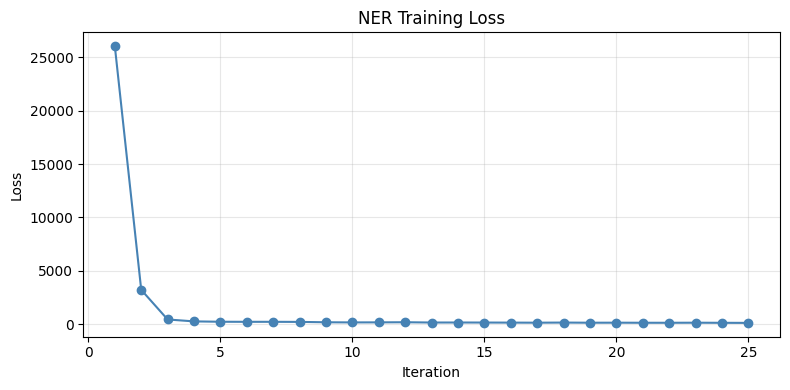

Loss went from 26058.36 to 121.51


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses_history)+1), losses_history, marker="o", color="steelblue")
plt.title("NER Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Loss went from", losses_history[0], "to", losses_history[-1])


## 8. Evaluate on Test Set

In [8]:
from spacy.scorer import Scorer

test_db_loaded = DocBin().from_disk(test_path)
test_docs      = list(test_db_loaded.get_docs(nlp_ner.vocab))

examples = []
for doc in test_docs:
    pred = nlp_ner(doc.text)
    examples.append(Example(pred, doc))

scorer  = Scorer()
results = scorer.score(examples)

print("Evaluation Results")
print("-" * 40)
ent_results = results.get("ents_per_type", {})

for label in sorted(ent_results.keys()):
    scores = ent_results[label]
    p = round(scores["p"] * 100, 1)
    r = round(scores["r"] * 100, 1)
    f = round(scores["f"] * 100, 1)
    print(f"  {label:20s}  P: {p:5.1f}%  R: {r:5.1f}%  F1: {f:5.1f}%")

overall = results.get("ents_f", 0)
print(f"\nOverall F1 Score: {round(overall*100, 2)}%")


Evaluation Results
----------------------------------------
  Certification         P: 100.0%  R: 100.0%  F1: 100.0%
  College               P: 100.0%  R: 100.0%  F1: 100.0%
  Company               P: 100.0%  R: 100.0%  F1: 100.0%
  Degree                P: 100.0%  R: 100.0%  F1: 100.0%
  Designation           P: 100.0%  R: 100.0%  F1: 100.0%
  Email                 P: 100.0%  R: 100.0%  F1: 100.0%
  Graduation_Year       P: 100.0%  R: 100.0%  F1: 100.0%
  Name                  P: 100.0%  R: 100.0%  F1: 100.0%
  Phone                 P: 100.0%  R: 100.0%  F1: 100.0%
  Skill                 P:  99.0%  R:  99.8%  F1:  99.4%

Overall F1 Score: 99.74%


## 9. Test on a Sample Resume

In [9]:
sample_resume = """
Rahul Sharma
rahul.sharma@gmail.com | 9876543210 | Bangalore

EDUCATION
B.Tech in Computer Science — IIT Delhi
Graduation Year: 2021

EXPERIENCE
Software Engineer — Infosys
3 years of experience.

SKILLS
Python, Django, PostgreSQL, Docker, AWS, Git

CERTIFICATIONS
AWS Certified Solutions Architect
"""

doc = nlp_ner(sample_resume)

print("Entities extracted from sample resume:")
print("-" * 40)
for ent in doc.ents:
    print(f"  [{ent.label_:20s}] {ent.text!r}")


Entities extracted from sample resume:
----------------------------------------
  [Name                ] 'Rahul Sharma'
  [Email               ] 'rahul.sharma@gmail.com'
  [Phone               ] '9876543210'
  [Degree              ] 'B.Tech in Computer Science'
  [College             ] 'IIT Delhi'
  [Graduation_Year     ] '2021'
  [Designation         ] 'Software Engineer'
  [Company             ] 'Infosys'
  [Skill               ] 'Python'
  [Skill               ] 'Django'
  [Skill               ] 'PostgreSQL'
  [Skill               ] 'Docker'
  [Skill               ] 'AWS'
  [Skill               ] 'Git'
  [Certification       ] 'AWS Certified Solutions Architect'


## 10. Save the Model

In [10]:
nlp_ner.to_disk(NER_MODEL_PATH)
print(f"Model saved to: {NER_MODEL_PATH}")

# Verify it loads correctly
test_load = spacy.load(NER_MODEL_PATH)
print("Model loads correctly!")
print(f"Pipe names: {test_load.pipe_names}")
print("\nStep 3 complete! Next: open step4_train_ranking_model.ipynb")


Model saved to: c:\Users\GARG\RESUMES PBL\models\ner_model
Model loads correctly!
Pipe names: ['ner']

Step 3 complete! Next: open step4_train_ranking_model.ipynb
